# Practica 01 - AAPI  
---
Grupo H: Joaquin Negrete y Pablo Suárez  
2026

Vamos a trabajar con ![River.jpg](./River.jpg)

## Tarea 1
Visualización de la imagen proporcionada para la práctica, separación de los tres canales de color que contiene.

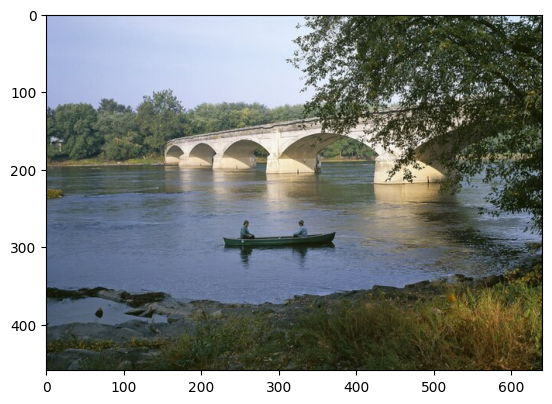

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image

img = Image.open("./River.jpg")
arr = np.array(img)
plt.imshow(img)
plt.show()

Mode: RGB
Size: (640, 459)


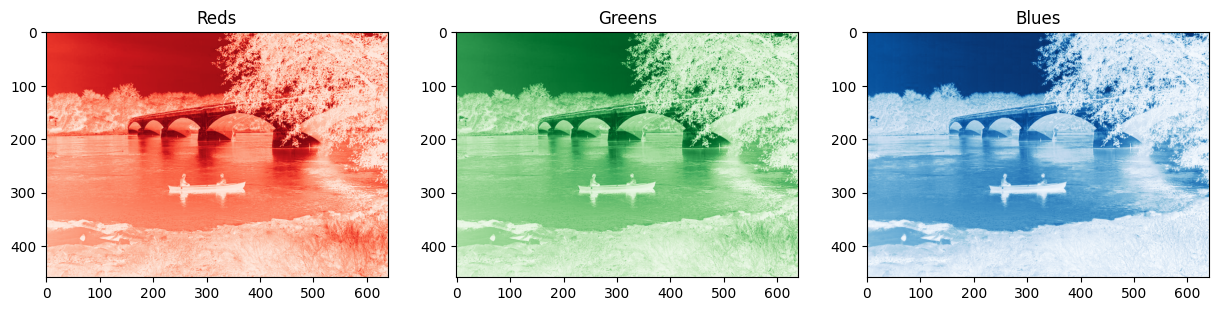

In [5]:
print(f"Mode: {img.mode}")
print(f"Size: {img.size}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = ["Reds", "Greens", "Blues"]
for i in range(3):
    axes[i].imshow(arr[:,:,i], cmap=names[i])
    axes[i].set_title(names[i])
plt.show()


## Tarea 2
Cálculo de valores estadísticos: media, desviación estándar y varianza de los canales


In [10]:
from math import sqrt

channels = [arr[:,:,i] for i in range(3)]

def img_mean(channel: np.ndarray) -> float:
    cum = 0
    for row in channel:
        cum += np.sum(row)

    return cum / channel.size

def img_variance(channel: np.ndarray) -> float:
    mean = img_mean(channel)
    cum = 0
    for row in channel:
        for el in row:
           cum += (el - mean) ** 2 

    return cum / channel.size

def img_std(channel: np.ndarray) -> float:
    return sqrt(img_variance(channel))

means = [img_mean(channel) for channel in channels]
stds = [img_std(channel) for channel in channels]
variances = [img_variance(channel) for channel in channels]

for i in range(len(channels)):
    print(f"{names[i]} channel - Mean: {means[i]}, Std: {stds[i]}, Variance: {variances[i]}")

Reds channel - Mean: 104.2929091775599, Std: 57.98217458448696, Variance: 3361.9325695459256
Greens channel - Mean: 110.23564474400871, Std: 57.96734531472056, Variance: 3360.213122836056
Blues channel - Mean: 107.35651552287581, Std: 72.97605938124727, Variance: 5325.505242815327


## Tarea 3
Realizar las operaciones aritméticas de suma y resta sobre las bandas que tengan la máxima y la mínima desviación estándard; así como las operaciones lógicas OR y AND.

La máxima es azul y la mínima es verde.  
Para binarizar los canales, como no tenemos un umbral específico, vamos a utilizar la media. 

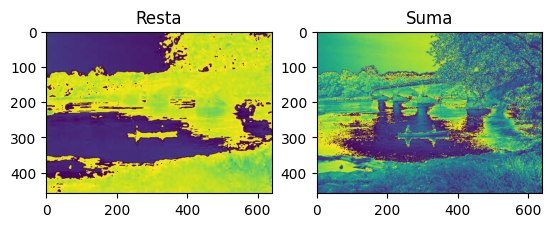

In [11]:
plt.subplot(1, 2, 1)
im_diff = channels[2] - channels[1]
plt.imshow(im_diff)
plt.title("Resta")

plt.subplot(1, 2, 2)
im_sum = channels[2] + channels[1]
plt.imshow(im_sum)
plt.title("Suma")

plt.show()

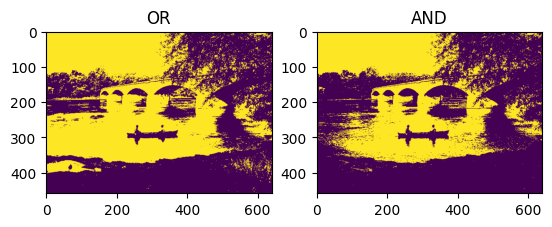

In [12]:
b_bin = (channels[2] > means[2]).astype(np.uint8)
g_bin = (channels[1] > means[1]).astype(np.uint8)

plt.subplot(1, 2, 1)
im_or = b_bin | g_bin
plt.imshow(im_or)
plt.title("OR")

plt.subplot(1, 2, 2)
im_and = b_bin & g_bin
plt.imshow(im_and)
plt.title("AND")

plt.show()

## Tarea 4

Obtener histograma de las bandas originales y con las imágenes de las operaciones aritméticas.

In [27]:
def im_histogram(im_channel: np.ndarray, length: int) -> np.ndarray:
    histogram = [0] * length

    for row in im_channel:
        for el in row:
            histogram[el] += 1

    return histogram

In [28]:
to_show = {
    "OR": im_or,
    "AND": im_and,
    "resta": im_diff,
    "suma": im_sum,
    "reds": channels[0],
    "greens": channels[1],
    "blues": channels[2]
}

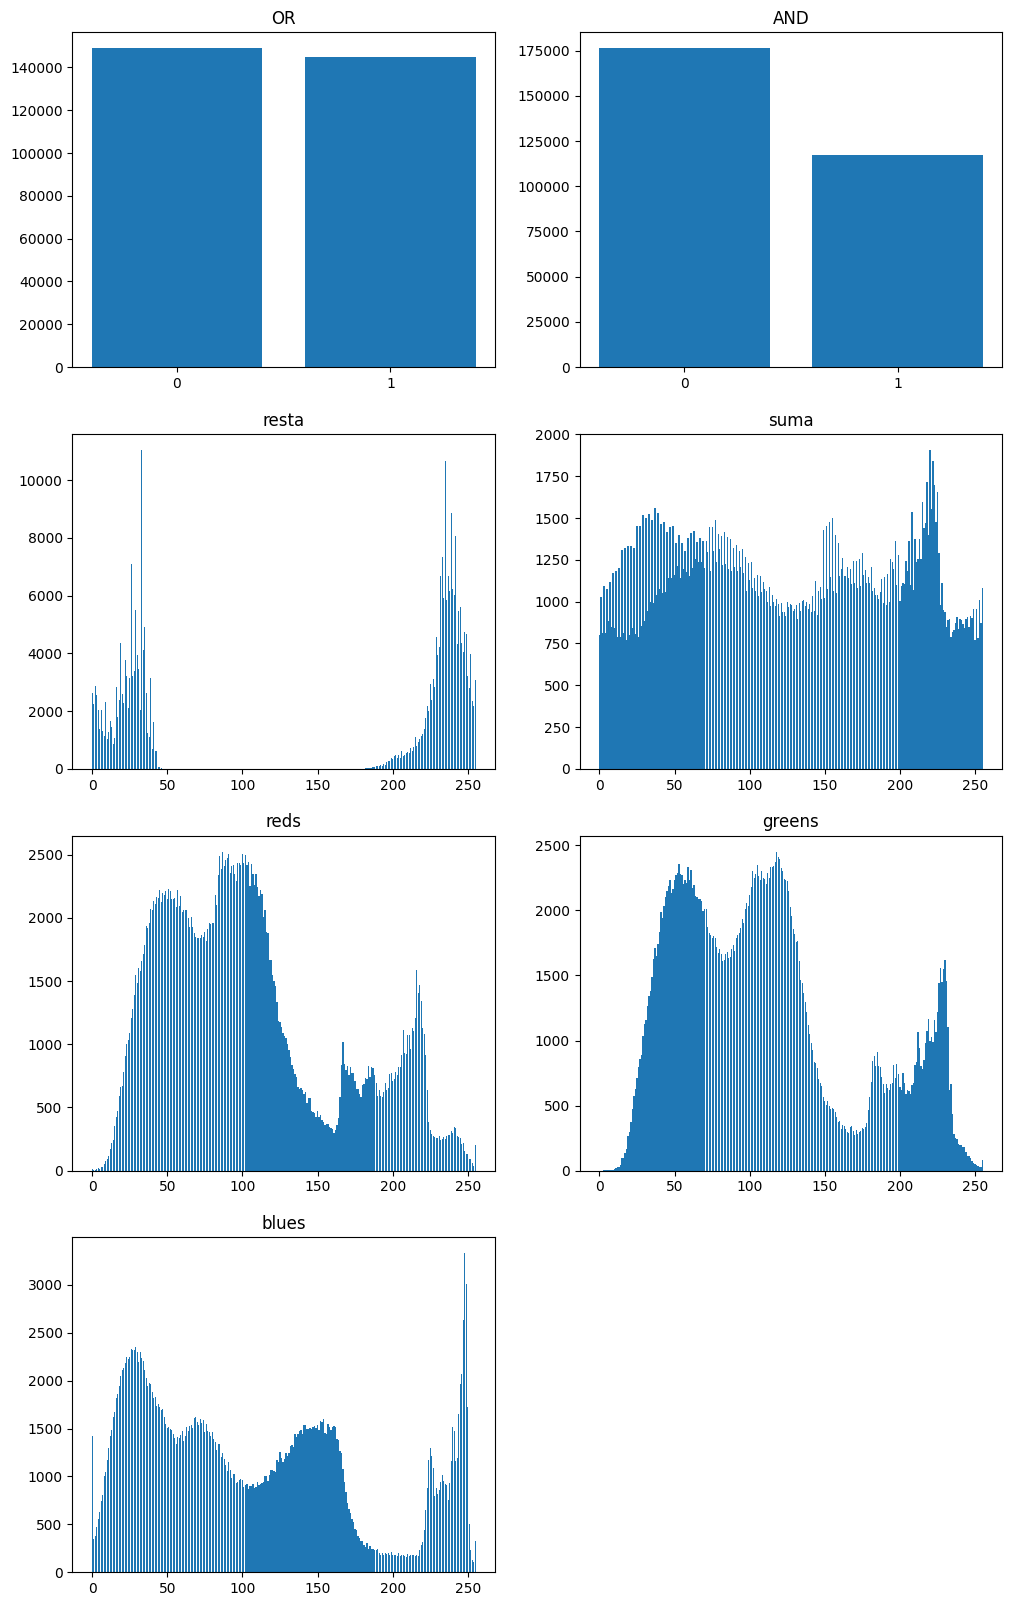

In [41]:
plt.figure(figsize=(12, 20))

for i, (name, channel) in enumerate(to_show.items()):
    plt.subplot(4, 2, i + 1)
    length = 2 if name in ["OR", "AND"] else 256
    hist = im_histogram(channel, length)
    plt.bar(range(length), hist)
    plt.title(name)

    if length == 2:
        plt.xticks([0, 1])

plt.show()

## Tarea 5

Implementar filtros en el dominio espacial: 3x3 y 5x5, para obtener imágenes suavizadas y con realce de bordes de la banda con mayor desviación estándar.

In [44]:
def conv_2d(img: np.ndarray, filter: np.ndarray) -> np.ndarray:
    padding = filter.shape[0] // 2

    # Add padding to the img
    img_copy = np.pad(img, padding)

    # Rotate the img
    filter_rot = np.flip(filter)

    # Correlate
    res = np.zeros(img.shape)
    x_size, y_size = filter.shape
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = img_copy[i:i + x_size, j:j + y_size]
            res[i, j] = np.sum(window * filter_rot)

    return res


In [46]:
smooth_filter_3 = np.ones((3, 3))
smooth_filter_5 = np.ones((5, 5))

edges_filter_3 = np.ones((3, 3)) * -1
edges_filter_3[1, 1] = 9
edges_filter_5 = np.ones((5, 5)) * -1
edges_filter_5[2, 2] = 24

blue_channel = channels[2]
to_show = {
    "smooth_img_3": conv_2d(blue_channel, smooth_filter_3),
    "smooth_img_5": conv_2d(blue_channel, smooth_filter_5),
    "edges_img_3": conv_2d(blue_channel, edges_filter_3),
    "edges_img_5": conv_2d(blue_channel, edges_filter_5)
}


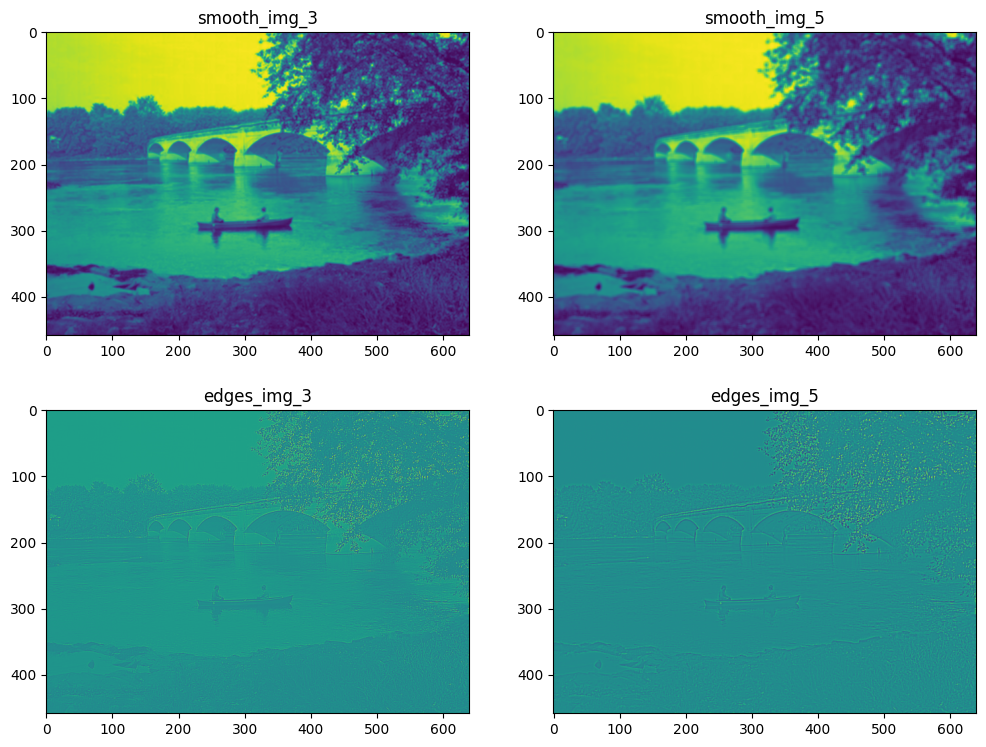

In [49]:
plt.figure(figsize=(12, 9))
for i, (name, img) in enumerate(to_show.items()):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(name)

plt.show()

## Tarea 6

Transformada de Fourier Discreta. Visualizar el espectro de potencia.

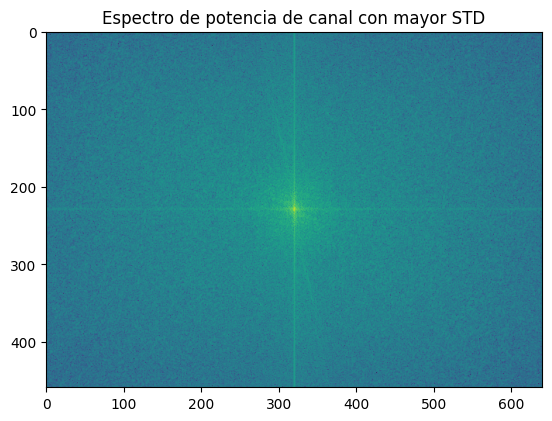

In [57]:
from scipy.fft import fft2, fftshift, ifft2, ifftshift

def centered_power_log(ft: np.ndarray) -> np.ndarray:
    return np.log1p(np.abs(fftshift(ft))) 

fft_blue = fft2(blue_channel)
plt.imshow(centered_power_log(fft_blue))
plt.title("Espectro de potencia de canal con mayor STD")
plt.show()

## Tarea 7

Diseñar filtros paso bajo y alto en el dominio de Fourier. Radio 10, 20 y 30.

In [60]:
def low_pass_mask(shape: tuple[int, int], radius: int) -> np.ndarray:
    rows, cols = shape
    center_row, center_col = rows // 2, cols // 2

    y, x = np.ogrid[:rows, :cols]
    dist_from_center = np.sqrt((y - center_row)**2 + (x - center_col)**2)

    return (dist_from_center <= radius).astype(float)

def high_pass_mask(shape: tuple[int, int], radius: int) -> np.ndarray:
    return 1.0 - low_pass_mask(shape, radius)

def apply_freq_filter(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    fft_img = fftshift(fft2(img))
    fft_filtered = fft_img * mask
    return np.real(ifft2(ifftshift(fft_filtered)))

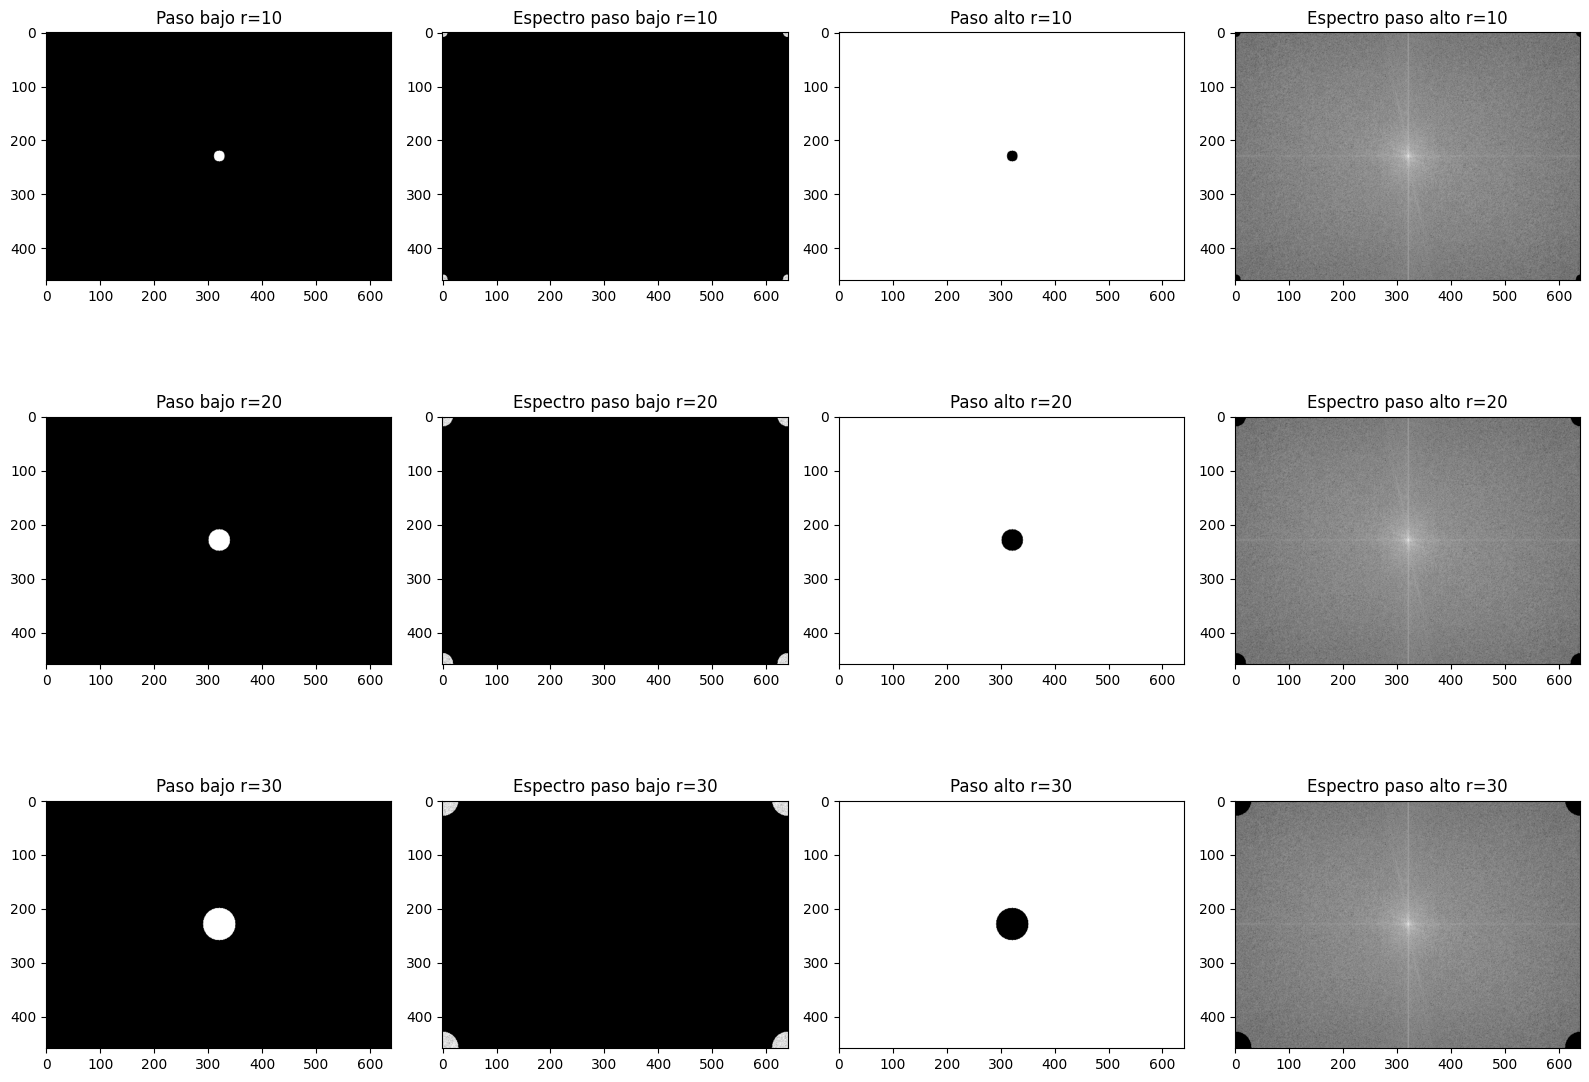

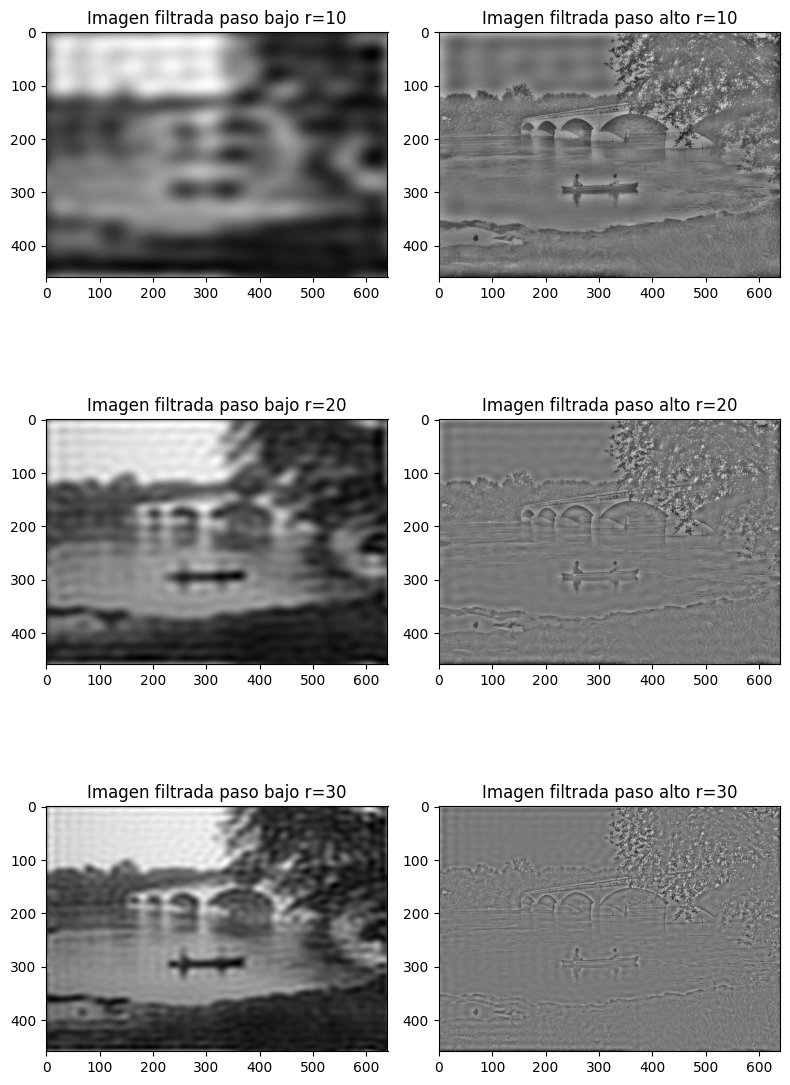

In [61]:
radios = [10, 20, 30]
img = blue_channel
fft_blue = fft2(img)

fig, axes = plt.subplots(len(radios), 4, figsize=(16, 4 * len(radios)))

for row, radius in enumerate(radios):
    lp_mask = low_pass_mask(img.shape, radius)
    hp_mask = high_pass_mask(img.shape, radius)

    lp_filtered = apply_freq_filter(img, lp_mask)
    hp_filtered = apply_freq_filter(img, hp_mask)

    axes[row, 0].imshow(lp_mask, cmap="gray")
    axes[row, 0].set_title(f"Paso bajo r={radius}")

    axes[row, 1].imshow(centered_power_log(fft_blue * lp_mask), cmap="gray")
    axes[row, 1].set_title(f"Espectro paso bajo r={radius}")

    axes[row, 2].imshow(hp_mask, cmap="gray")
    axes[row, 2].set_title(f"Paso alto r={radius}")

    axes[row, 3].imshow(centered_power_log(fft_blue * hp_mask), cmap="gray")
    axes[row, 3].set_title(f"Espectro paso alto r={radius}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(radios), 2, figsize=(8, 4 * len(radios)))

for row, radius in enumerate(radios):
    lp_mask = low_pass_mask(img.shape, radius)
    hp_mask = high_pass_mask(img.shape, radius)

    lp_filtered = apply_freq_filter(img, lp_mask)
    hp_filtered = apply_freq_filter(img, hp_mask)

    axes[row, 0].imshow(lp_filtered, cmap="gray")
    axes[row, 0].set_title(f"Imagen filtrada paso bajo r={radius}")

    axes[row, 1].imshow(hp_filtered, cmap="gray")
    axes[row, 1].set_title(f"Imagen filtrada paso alto r={radius}")

plt.tight_layout()
plt.show()